# Illustration Exercise — Introduction

## Context

TF-IDF (Term Frequency–Inverse Document Frequency) measures how discriminating a word is for a specific document relative to a corpus. This exercise fetches recent news headlines for three major financial firms — AAPL, MSFT, JPM — via the `yfinance` API and visualises the top-20 TF-IDF terms as a heatmap. High-weight cells reveal company-specific vocabulary: terms that appear frequently in one firm's coverage but rarely across the whole corpus.

## Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import yfinance as yf
from sklearn.feature_extraction.text import TfidfVectorizer
import pathlib, warnings
warnings.filterwarnings("ignore")

plt.style.use(["science", "no-latex"])

def get_headlines(sym, n=12):
    ticker = yf.Ticker(sym)
    news = ticker.news or []
    out = []
    for item in news[:n]:
        title = (item.get("title") or
                 item.get("content", {}).get("title") or "")
        if title:
            out.append(title)
    return out

tickers = ["AAPL", "MSFT", "JPM"]
corpus, labels = [], []
for t in tickers:
    for h in get_headlines(t):
        corpus.append(h)
        labels.append(t)

print(f"Fetched {len(corpus)} headlines across {len(tickers)} tickers")

Fetched 30 headlines across 3 tickers


## Figure

Saved to C:\Users\jfimb\Documents\book-course-template\book\chapters\01-intro\figures\fig_illustration.pdf


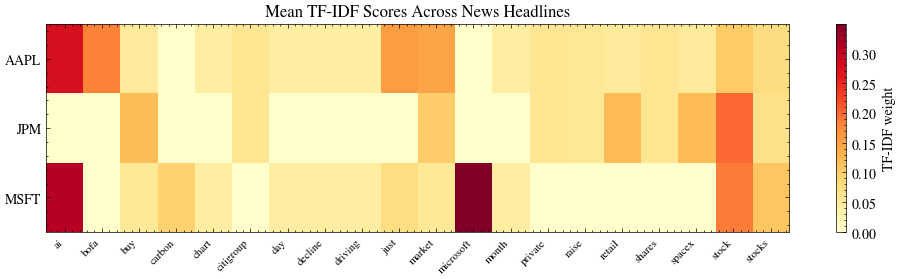

In [2]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=20)
X = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()

df = pd.DataFrame(X.toarray(), columns=terms)
df["ticker"] = labels
agg = df.groupby("ticker").mean()

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(agg.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(terms)))
ax.set_xticklabels(terms, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(agg.index)))
ax.set_yticklabels(agg.index)
ax.set_title("Mean TF-IDF Scores Across News Headlines")
plt.colorbar(im, ax=ax, label="TF-IDF weight")
fig.tight_layout()

out_path = pathlib.Path("../../../book/chapters/01-intro/figures/fig_illustration.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path.resolve()}")
plt.show()

## Your Turn

Add a fourth ticker of your choice (e.g., `"TSLA"` or `"GS"`), regenerate the heatmap, and describe in one paragraph which terms are unique to that company and what they reveal about its news coverage relative to the other three firms.

# Exercises — Lecture 1: Introduction to LLMs in Finance

See `course/lectures/01-intro/exercises.md` for the problem statements.

**Exercise 1.1 [B]:** Bag-of-Words and TF-IDF on earnings call sentences.

**Exercise 1.2 [I]:** PCA visualisation of financial word embeddings.

**Exercise 1.3 [A]:** Self-attention from scratch in NumPy.

In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1.1 [B]

[Your solution here]

## Exercise 1.2 [I]

[Your solution here]

## Exercise 1.3 [A]

[Your solution here]